In [1]:
#!/usr/bin/env python
# coding: utf-8
import scipy.io
import os
import sys
import numpy as np
import h5py
from scipy.interpolate import interp1d
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sbi import utils as sbi_utils
from sbi.inference import SNPE
from sbi.utils.get_nn_models import posterior_nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import random

# Set seeds for reproducibility
random.seed(42)  # For Python's built-in random module
np.random.seed(42)  # For NumPy
torch.manual_seed(42)  # PyTorch
# Optionally, set TensorFlow to deterministic mode for even more reproducibility
os.environ['TF_DETERMINISTIC_OPS'] = '1'

if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


Ask the user to target the name format

In [2]:
name_format = "SBI_Bz_UQ_test"
print("Note: use results16.mat which has 10000 datasets; B only has positive Z values, learning rate 0.0001, batch size 32.")
file_path = os.path.join('MATLAB_DATA', 'results16.mat')  # Replace with your actual file path
def generate_filename(base_name, extension):
    return f"{name_format}_{base_name}.{extension}"

posterior_path = os.path.join("/home/botingl/machine learning/results/SBI_Bz_run23_posterior.pt")
posterior = torch.load(posterior_path)
print("Model loaded successfully.")

Note: use results16.mat which has 10000 datasets; B only has positive Z values, learning rate 0.0001, batch size 32.
Model loaded successfully.


Define the list of files that should be processed as HDF5 files

In [3]:
h5_file_numbers = {3, 6, 7, 9}

Function to load data from .h5 file

In [4]:
def load_h5_data(file_path):
    with h5py.File(file_path, 'r') as hdf:
        results_group = hdf['results']
        B_MAG_refs = results_group['B_MAG'][()]
        EDC_MAG_refs = results_group['EDC_MAG'][()]
        X_refs = results_group['X'][()]
        I_refs = results_group['I'][()]
        B_MAG_raw = [hdf[ref][()] for ref in B_MAG_refs.flatten()]
        EDC_MAG_raw = [hdf[ref][()] for ref in EDC_MAG_refs.flatten()]
        X_raw = [hdf[ref][()] for ref in X_refs.flatten()]
        I_raw = [hdf[ref][()] for ref in I_refs.flatten()]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

Function to load data from .mat file

In [5]:
def load_mat_data(file_path):
    mat_contents = scipy.io.loadmat(file_path)
    results = mat_contents['results']
    B_MAG_raw = [result['B_MAG'][0] for result in results[0]]
    EDC_MAG_raw = [result['EDC_MAG'][0] for result in results[0]]
    X_raw = [result['X'][0] for result in results[0]]  # Scaling X values
    I_raw = [result['I'][0] for result in results[0]]
    return B_MAG_raw, EDC_MAG_raw, X_raw, I_raw

Function to resample and smooth data

In [6]:
def resample_and_smooth(X, I, new_length):
    X_new = np.linspace(6562.3, 6563.3, num=new_length)
    f = interp1d(X, I, kind='cubic', fill_value="extrapolate")
    I_new = f(X_new)
    return X_new, I_new

Function to process data

In [7]:
def process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw, fixed_length=1200):
    X_data, I_data, B_MAG_data, EDC_MAG_data = [], [], [], []
    for i in range(len(X_raw)):
        X = np.squeeze(X_raw[i])
        I = np.squeeze(I_raw[i])
        B = np.squeeze(B_MAG_raw[i])
        EDC = np.squeeze(EDC_MAG_raw[i])
        X_scaled = X * 10**10
        X_resampled, I_resampled = resample_and_smooth(X_scaled, I, fixed_length)
        X_data.append(X_resampled)
        I_data.append(I_resampled)
        B_MAG_data.append(B)
        EDC_MAG_data.append(EDC)
    return np.array(B_MAG_data), np.array(EDC_MAG_data), np.array(X_data), np.array(I_data)

Main function to determine the type of file and load data accordingly

In [8]:
def load_and_process_file(file_path):
    file_name = os.path.basename(file_path)
    
    # Extract the file number (e.g., results1, results5, etc.)
    file_number = int(file_name.lstrip('results').rstrip('.mat'))
    
    if file_number in h5_file_numbers:
        # It's an HDF5 file
        print(f"Processing {file_name} as an HDF5 file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_h5_data(file_path)
    else:
        # It's a standard .mat file
        print(f"Processing {file_name} as a .mat file...", flush=True)
        B_MAG_raw, EDC_MAG_raw, X_raw, I_raw = load_mat_data(file_path)
    
    # Process the loaded data
    B_MAG_data, EDC_MAG_data, X_data, I_data = process_data(B_MAG_raw, EDC_MAG_raw, X_raw, I_raw)
    
    return B_MAG_data, EDC_MAG_data, X_data, I_data

File paths for training and testing data

In [9]:
B_MAG_data, EDC_MAG_data, X_data, I_data = load_and_process_file(file_path)


# Data is now loaded and processed.
print("Data reading completed.")


Processing results16.mat as a .mat file...
Data reading completed.


In [10]:

means = np.mean(I_data, axis=0)
stds = np.std(I_data, axis=0)

start_index = 0
end_index = I_data.shape[1] - 1

for i in range(I_data.shape[1]):
    if stds[i] >= 0.01:
        start_index = i
        break


for i in range(I_data.shape[1] - 1, -1, -1):
    if stds[i] >= 0.01:
        end_index = i
        break

I_data_filtered = I_data[:, start_index:end_index + 1]
means_filtered = means[start_index:end_index + 1]
stds_filtered = stds[start_index:end_index + 1]
print(f"Data filtered from column {start_index} to {end_index}.")


# Normalize the data
normalized_I = (I_data_filtered - means_filtered) / stds_filtered

def resample_and_smooth_data(normalized_data, new_length=1200):
    resampled_data = []
    
    for row in normalized_data:
        original_length = len(row)
        # Define the original x values (relative position in the original data)
        x_original = np.linspace(0, 1, num=original_length)
        
        # Define the new x values (for the desired length)
        x_new = np.linspace(0, 1, num=new_length)
        
        # Use cubic interpolation to resample and smooth
        f = interp1d(x_original, row, kind='cubic', fill_value="extrapolate")
        resampled_row = f(x_new)
        
        resampled_data.append(resampled_row)
    
    return np.array(resampled_data)

# Resample and smooth the normalized data to ensure each element has a length of 1200
normalized_I_resampled = resample_and_smooth_data(normalized_I, new_length=1200)

# Concatenate B and E to form target data
input_data = normalized_I_resampled


# Normalize target and target data

from sklearn.preprocessing import MinMaxScaler

# Assuming B_MAG_data and EDC_MAG_data are loaded as NumPy arrays
# B3 is B_MAG_data[:, 2], and EDC_MAG_data consists of E1, E2, E3
B3 = B_MAG_data[:, 2].reshape(-1, 1)  # B3 component
E1 = EDC_MAG_data[:, 0].reshape(-1, 1)  # E1 component
E2 = EDC_MAG_data[:, 1].reshape(-1, 1)  # E2 component
E3 = EDC_MAG_data[:, 2].reshape(-1, 1)  # E3 component

# Create separate MinMaxScaler instances for each component
scaler_B3 = MinMaxScaler(feature_range=(0, 1))
scaler_E1 = MinMaxScaler(feature_range=(0, 1))
scaler_E2 = MinMaxScaler(feature_range=(0, 1))
scaler_E3 = MinMaxScaler(feature_range=(0, 1))

# Fit and transform each component separately
B3_scaled = scaler_B3.fit_transform(B3)
E1_scaled = scaler_E1.fit_transform(E1)
E2_scaled = scaler_E2.fit_transform(E2)
E3_scaled = scaler_E3.fit_transform(E3)

# Recombine the scaled components back into target_data
target_data = np.hstack((B3_scaled, E1_scaled, E2_scaled, E3_scaled))

# Now, target_data_scaled contains B3, E1, E2, E3 all scaled between 0 and 1


# Convert to PyTorch tensors
target_data_tensor = torch.tensor(target_data, dtype=torch.float32)
input_data_tensor = torch.tensor(input_data, dtype=torch.float32)


# Split into training and testing sets
target_data_train, target_data_test, input_data_train, input_data_test = train_test_split(
    target_data, input_data, test_size=0.2, random_state=42
)

target_data_train_tensor = torch.tensor(target_data_train, dtype=torch.float32)
target_data_test_tensor = torch.tensor(target_data_test, dtype=torch.float32)
input_data_train_tensor = torch.tensor(input_data_train, dtype=torch.float32)
input_data_test_tensor = torch.tensor(input_data_test, dtype=torch.float32)

print("Data organized.", flush=True)

Data filtered from column 105 to 1097.
Data organized.


Data is now loaded and processed.

In [11]:
prior_min = torch.tensor([target_data_train_tensor.min().item()] * target_data_train_tensor.shape[1])
prior_max = torch.tensor([target_data_train_tensor.max().item()] * target_data_train_tensor.shape[1])
margin = 0.1 * (prior_max - prior_min)
prior = sbi_utils.BoxUniform(low=prior_min - margin, high=prior_max + margin)

Whole model evaluation (NMSE, rMAE, R²)

In [12]:
def evaluate_whole_model(y_true, y_pred):
    nmse = mean_squared_error(y_true, y_pred) / np.var(y_true)
    rmae = mean_absolute_error(y_true, y_pred) / np.mean(np.abs(y_true))
    r2 = r2_score(y_true, y_pred)
    return nmse, rmae, r2

In [13]:
print("Start to evaluate the training set.", flush=True)
# np.random.seed(42)
size = len(input_data_train) if len(input_data_train) < 1000 else 1000
train_subset_indices = np.random.choice(len(input_data_train), size=size, replace=False)
train_input_data_subset = input_data_train[train_subset_indices]
train_target_data_subset = target_data_train[train_subset_indices]

Start to evaluate the training set.


Component-wise evaluation (MSE, MAE, R²)

In [17]:
import time
import torch

# Initialize lists to store mean predictions and uncertainties
mean_predictions_train = []
std_dev_predictions_train = []  # For storing uncertainty (standard deviation)

for i in tqdm(range(len(train_input_data_subset)), desc="Processing samples", leave=True, file=sys.stdout):
    train_input = train_input_data_subset[i]  # This is the X and I for this training sample
    
    try:
        # Sample the posterior 1000 times for the given input
        predicted_posterior = posterior.sample((1000,), x=train_input, show_progress_bars=False)
        
        # Extract the mean prediction for B and E
        predicted_mean = predicted_posterior.mean(dim=0)
        predicted_std_dev = predicted_posterior.std(dim=0)  # Calculate standard deviation for uncertainty
        
        # Append the results
        mean_predictions_train.append(predicted_mean)
        std_dev_predictions_train.append(predicted_std_dev)
    
    except Exception as e:
        print(f"Error encountered during prediction for sample {i}: {e}")
        mean_predictions_train.append(torch.tensor([float('nan')] * 4))  # Handle error gracefully
        std_dev_predictions_train.append(torch.tensor([float('nan')] * 4))

    sys.stdout.flush()  # Manually flush output

# Convert lists of tensors to a single tensor for easier manipulation
mean_predictions_train = torch.stack(mean_predictions_train).numpy()  # Shape: (num_samples, 4)
std_dev_predictions_train = torch.stack(std_dev_predictions_train).numpy()  # Shape: (num_samples, 4)

# Calculate confidence intervals (e.g., 95%)
lower_bound_train = mean_predictions_train - 1.96 * std_dev_predictions_train
upper_bound_train = mean_predictions_train + 1.96 * std_dev_predictions_train

# Results: `mean_predictions_train`, `std_dev_predictions_train`, `lower_bound`, `upper_bound`
print("Mean Predictions:", mean_predictions_train)
print("Standard Deviations:", std_dev_predictions_train)


Processing samples: 100%|██████████| 1000/1000 [05:02<00:00,  3.31it/s]
Mean Predictions: [[0.5090863  0.06462029 0.1675292  0.03278088]
 [0.6073788  0.9707607  0.43027708 0.19028738]
 [0.63686025 0.16189468 0.24120052 0.3228263 ]
 ...
 [0.58250654 0.67699623 0.7762646  0.9338334 ]
 [0.88210124 0.62316835 0.45265952 0.5529204 ]
 [0.78201014 0.7278755  0.3231292  0.04944656]]
Standard Deviations: [[0.24867973 0.02311019 0.09558956 0.02127257]
 [0.00285801 0.00217705 0.00174065 0.00443595]
 [0.1061372  0.03413276 0.04358932 0.00987022]
 ...
 [0.00357846 0.00734547 0.00134963 0.00384382]
 [0.00962993 0.0024261  0.01898772 0.00124107]
 [0.03716964 0.00291323 0.00746119 0.0082005 ]]


Generate predictions for the test set

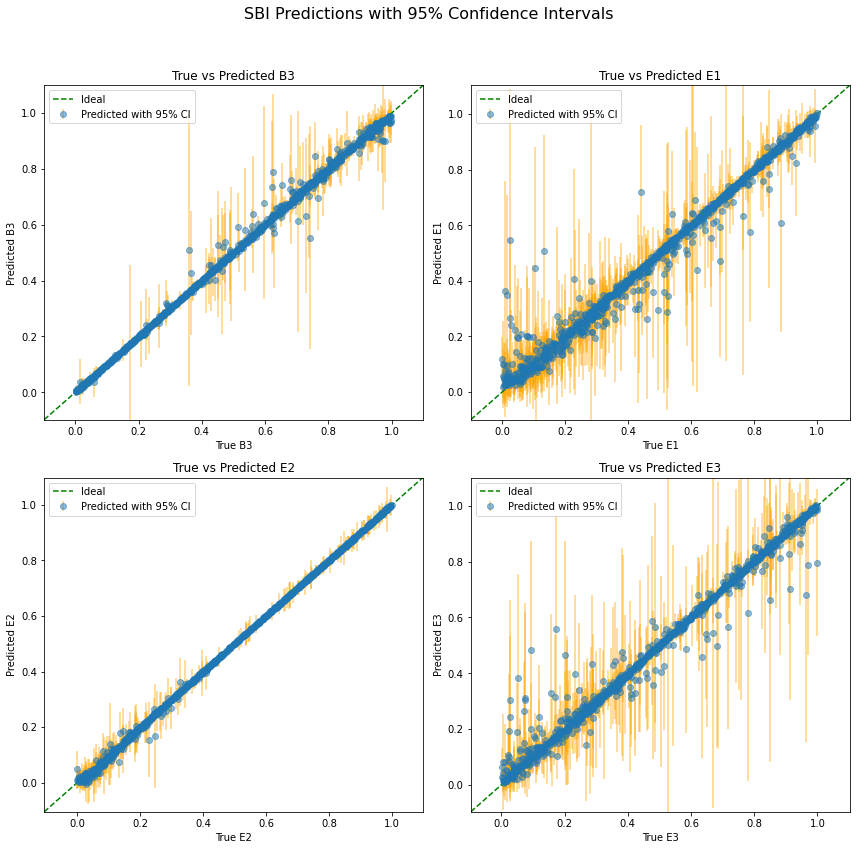

In [18]:
import matplotlib.pyplot as plt

# Assuming the following variables are already computed:
# mean_predictions_train: (num_samples, 4) -> Mean predictions for each target component
# lower_bound: (num_samples, 4) -> Lower bound of confidence interval
# upper_bound: (num_samples, 4) -> Upper bound of confidence interval
# target_data_train: (num_samples, 4) -> True values for each target component

plt.figure(figsize=(12, 12))

# Plot for each target variable
for i, target_name in enumerate(['B3', 'E1', 'E2', 'E3']):
    plt.subplot(2, 2, i + 1)
    
    # Calculate error bars
    errors = std_dev_predictions_train[:, i] * 1.96  # Symmetric CI, no need for bounds
    
    # Scatter plot with error bars
    plt.errorbar(
        train_target_data_subset[:, i],  # True values
        mean_predictions_train[:, i],  # Predicted mean
        yerr=errors,  # Error bars (asymmetric)
        fmt='o',  # Circle marker
        ecolor='orange',  # Error bar color
        alpha=0.5,  # Transparency
        label='Predicted with 95% CI'
    )
    
    # Plot the ideal diagonal line
    min_val = min(train_target_data_subset[:, i].min(), mean_predictions_train[:, i].min()) - 0.1
    max_val = max(train_target_data_subset[:, i].max(), mean_predictions_train[:, i].max()) + 0.1
    plt.plot([min_val, max_val], [min_val, max_val], 'g--', label='Ideal')
    
    # Set limits, labels, and title
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.xlabel(f'True {target_name}')
    plt.ylabel(f'Predicted {target_name}')
    plt.title(f'True vs Predicted {target_name}')
    plt.legend()

# Adjust layout and add a title for the whole figure
plt.suptitle('SBI Predictions with 95% Confidence Intervals', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to avoid overlap with the suptitle
figure_test_file = os.path.join("/home/botingl/machine learning", generate_filename("Predictions with 95% Confidence Intervals (Train Data)", "png"))
plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()


In [19]:
# Initialize lists to store mean predictions and uncertainties
mean_predictions_test = []
std_dev_predictions_test = []  # For storing uncertainty (standard deviation)

for i in tqdm(range(len(input_data_test)), desc="Processing samples", leave=True, file=sys.stdout):
    train_input = input_data_test[i]  # This is the X and I for this training sample
    
    try:
        # Sample the posterior 1000 times for the given input
        predicted_posterior = posterior.sample((1000,), x=train_input, show_progress_bars=False)
        
        # Extract the mean prediction for B and E
        predicted_mean = predicted_posterior.mean(dim=0)
        predicted_std_dev = predicted_posterior.std(dim=0)  # Calculate standard deviation for uncertainty
        
        # Append the results
        mean_predictions_test.append(predicted_mean)
        std_dev_predictions_test.append(predicted_std_dev)
    
    except Exception as e:
        print(f"Error encountered during prediction for sample {i}: {e}")
        mean_predictions_test.append(torch.tensor([float('nan')] * 4))  # Handle error gracefully
        std_dev_predictions_test.append(torch.tensor([float('nan')] * 4))

    sys.stdout.flush()  # Manually flush output

# Convert lists of tensors to a single tensor for easier manipulation
mean_predictions_test = torch.stack(mean_predictions_test).numpy()  # Shape: (num_samples, 4)
std_dev_predictions_test = torch.stack(std_dev_predictions_test).numpy()  # Shape: (num_samples, 4)

# Calculate confidence intervals (e.g., 95%)
lower_bound_test = mean_predictions_test - 1.96 * std_dev_predictions_test
upper_bound_test = mean_predictions_test + 1.96 * std_dev_predictions_test

# Results: `mean_predictions_train`, `std_dev_predictions_train`, `lower_bound`, `upper_bound`
print("Mean Predictions:", mean_predictions_test)
print("Standard Deviations:", std_dev_predictions_test)


Processing samples: 100%|██████████| 2000/2000 [09:14<00:00,  3.61it/s]
Mean Predictions: [[0.93588173 0.6990415  0.87729895 0.5336283 ]
 [0.9395127  0.82549286 0.87250173 0.36794007]
 [0.77647877 0.9614665  0.8231617  0.12723444]
 ...
 [0.14341201 0.1587331  0.99283504 0.2665769 ]
 [0.73789114 0.4445215  0.08158592 0.28014317]
 [0.5939236  0.06270668 0.27646124 0.0671128 ]]
Standard Deviations: [[0.01663372 0.00770593 0.0156401  0.0104604 ]
 [0.0186841  0.00776115 0.01933957 0.02659687]
 [0.01704173 0.00736661 0.00235814 0.01081777]
 ...
 [0.00814117 0.08372191 0.00290257 0.07316343]
 [0.05608535 0.00574925 0.05577224 0.00993064]
 [0.14528531 0.03552267 0.04269061 0.03758232]]


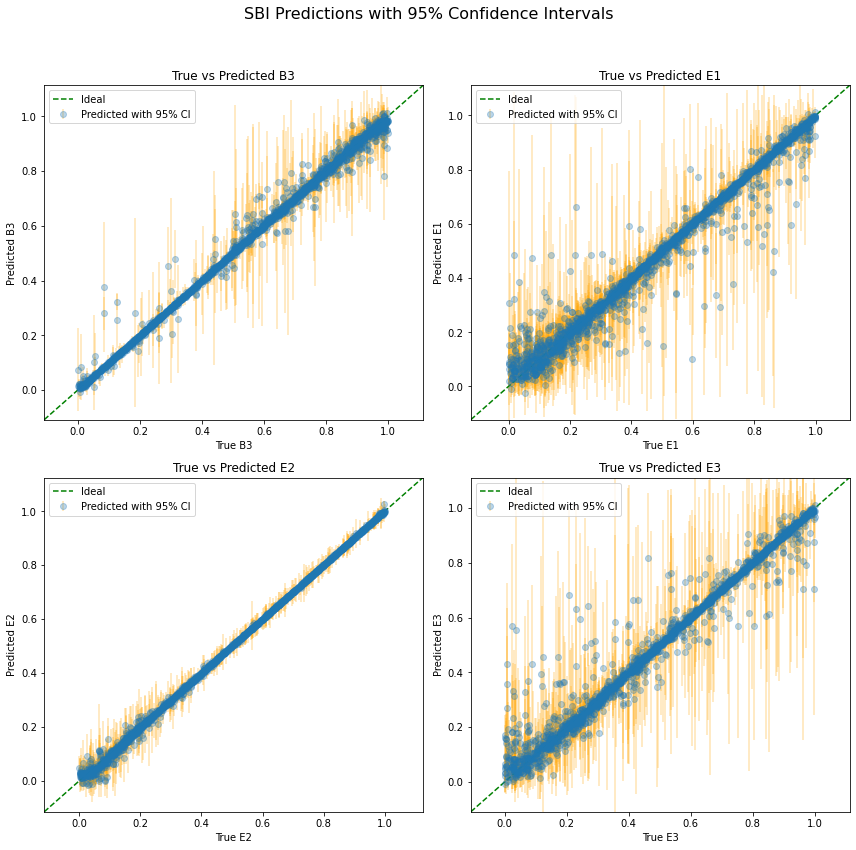

In [20]:
import matplotlib.pyplot as plt

# Assuming the following variables are already computed:
# mean_predictions_train: (num_samples, 4) -> Mean predictions for each target component
# lower_bound: (num_samples, 4) -> Lower bound of confidence interval
# upper_bound: (num_samples, 4) -> Upper bound of confidence interval
# target_data_train: (num_samples, 4) -> True values for each target component

plt.figure(figsize=(12, 12))

# Plot for each target variable
for i, target_name in enumerate(['B3', 'E1', 'E2', 'E3']):
    plt.subplot(2, 2, i + 1)
    
    # Calculate error bars
    errors = std_dev_predictions_test[:, i] * 1.96  # Symmetric CI, no need for bounds

    
    # Scatter plot with error bars
    plt.errorbar(
        target_data_test[:, i],  # True values
        mean_predictions_test[:, i],  # Predicted mean
        yerr=errors,  # Error bars (asymmetric)
        fmt='o',  # Circle marker
        ecolor='orange',  # Error bar color
        alpha=0.3,  # Transparency
        label='Predicted with 95% CI'
    )
    
    # Plot the ideal diagonal line
    min_val = min(target_data_test[:, i].min(), mean_predictions_test[:, i].min()) - 0.1
    max_val = max(target_data_test[:, i].max(), mean_predictions_test[:, i].max()) + 0.1
    plt.plot([min_val, max_val], [min_val, max_val], 'g--', label='Ideal')
    
    # Set limits, labels, and title
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.xlabel(f'True {target_name}')
    plt.ylabel(f'Predicted {target_name}')
    plt.title(f'True vs Predicted {target_name}')
    plt.legend()

# Adjust layout and add a title for the whole figure
plt.suptitle('SBI Predictions with 95% Confidence Intervals', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to avoid overlap with the suptitle
figure_test_file = os.path.join("/home/botingl/machine learning", generate_filename("Predictions with 95% Confidence Intervals (Test Data)", "png"))
plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()
